In [65]:
from langgraph.graph import StateGraph , START , END 
from typing import TypedDict , List , Annotated 
from langchain_core.messages import BaseMessage , HumanMessage 
from langgraph.checkpoint.memory import MemorySaver


In [66]:
import os
from dotenv import load_dotenv
from langchain_huggingface import HuggingFaceEndpoint, ChatHuggingFace

# load environment
load_dotenv()
# check token
token = os.getenv("HUGGINGFACEHUB_API_TOKEN")
if not token:
    print("Error: HUGGINGFACEHUB_API_TOKEN is not set in the .env file.")
else:
    print("Done")
#  Setup the Endpoint
repo_id = "meta-llama/Llama-3.1-8B-Instruct"

llm_H = HuggingFaceEndpoint(
    repo_id=repo_id,
    task="text-generation",
    max_new_tokens=512,
    temperature=0.7,
    huggingfacehub_api_token=token,
)
#  Wrap it in ChatHuggingFace (This handles the "conversational" format for you)
model = ChatHuggingFace(llm=llm_H)

Done


In [67]:
from langgraph.graph.message import add_messages
class ChatState(TypedDict):
    messages : Annotated[List[BaseMessage], add_messages]

In [68]:
checkpointer = MemorySaver()
graph = StateGraph(ChatState)

In [69]:
def chat(state: ChatState):
    # query from user 
    messages = state["messages"]
    # llm 
    response = model.invoke(messages)
    #store state 
    return {"messages": [response]}

In [70]:
graph.add_node("chat", chat)

In [71]:
graph.add_edge(START, "chat")
graph.add_edge("chat", END)
chatbot = graph.compile(checkpointer=checkpointer)


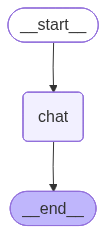

In [72]:
chatbot

In [73]:
initial_state = {
    "messages" : [HumanMessage(content="What is the capital of Pakistan?")]
}

In [74]:
# chatbot.invoke(initial_state)['messages'][-1].content

Feel Like Chatbot

In [ ]:
thread_id = '1'
while True:
    user = input("User: ")
    print("User : ", user)
    if user.strip().lower() in ["exit","bye"]:
        print("Exiting the chatbot. Goodbye!")
        break
    config = {"configurable": {"thread_id": thread_id}}
    response = chatbot.invoke({"messages": [HumanMessage(content=user)]}, config = config )
    print("AI:", response['messages'][-1].content)